# Shapash in Jupyter - Imbalanced Titanic Classification

In this tutorial you will:
- Build a binary classifier on an imbalanced Titanic dataset
- Compare a baseline model and a weighted model
- Focus on precision, recall, and F1-score for the minority class
- Explain the weighted model with Shapash and prepare the webapp launch

In [ ]:
import numpy as np
import pandas as pd

from category_encoders import one_hot
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
from sklearn.model_selection import train_test_split

from shapash import SmartExplainer
from shapash.data.data_loader import data_loading

## 1. Load and prepare Titanic data

In [2]:
titanic_df, titanic_dict = data_loading("titanic")

# Same feature engineering style as webapp_launch.py
titanic_df["Pclass"] = titanic_df["Pclass"].map({"First class": 1, "Second class": 2, "Third class": 3})

features = ["Pclass", "Age", "Sex", "SibSp", "Parch"]
target_name = "Survived"

X = titanic_df[features]
y = titanic_df[target_name].to_frame()

feature_dict = {
    "Pclass": "Ticket class",
    "Age": "Age",
    "Sex": "Sex",
    "SibSp": "Number of siblings/spouses aboard",
    "Parch": "Number of parents/children aboard",
}

postprocess = {
    "Age": {"type": "suffix", "rule": " years old"},
    "Sex": {"type": "transcoding", "rule": {"male": "Man", "female": "Woman"}},
    "Pclass": {"type": "transcoding", "rule": {1: "First", 2: "Second", 3: "Third"}},
}

label_dict = {0: "Deceased", 1: "Survived"}

X.head()

,Pclass,Age,Sex,SibSp,Parch
PassengerId,,,,,
1,3,22.0,male,1,0
2,1,38.0,female,1,0
3,3,26.0,female,0,0
4,1,35.0,female,1,0
5,3,35.0,male,0,0


## 2. Encode and split train/test

In [3]:
encoder = one_hot.OneHotEncoder(titanic_df, cols=["Sex"])
X_enc = encoder.fit_transform(X)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_enc,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print("Train target distribution (initial):")
print(y_train_full[target_name].value_counts(normalize=True).rename("ratio"))

Train target distribution (initial):
Survived
0    0.616766
1    0.383234
Name: ratio, dtype: float64


## 3. Create an imbalanced training sample

We keep all majority class examples (`Survived = 0`) and downsample the minority class (`Survived = 1`).

In [4]:
y_train_series = y_train_full[target_name]
majority_idx = y_train_series[y_train_series == 0].index
minority_idx = y_train_series[y_train_series == 1].index

# Keep about 15% positives compared to negatives for a strong imbalance
rng = np.random.default_rng(seed=42)
n_minority_kept = max(1, int(0.15 * len(majority_idx)))
n_minority_kept = min(n_minority_kept, len(minority_idx))
minority_idx_kept = rng.choice(minority_idx.to_numpy(), size=n_minority_kept, replace=False)

imbalanced_idx = np.concatenate([majority_idx.to_numpy(), minority_idx_kept])
X_train_imb = X_train_full.loc[imbalanced_idx].sort_index()
y_train_imb = y_train_full.loc[imbalanced_idx].sort_index()

print("Train target distribution (imbalanced):")
print(y_train_imb[target_name].value_counts(normalize=True).rename("ratio"))

Train target distribution (imbalanced):
Survived
0    0.871036
1    0.128964
Name: ratio, dtype: float64


## 4. Train and evaluate baseline vs weighted model

In [5]:
def evaluate_binary_model(model, X_eval, y_eval, model_name):
    y_true = y_eval[target_name]
    y_pred = model.predict(X_eval)
    return pd.Series(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision_minority": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            "recall_minority": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            "f1_minority": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        }
    )

In [6]:
baseline_model = LGBMClassifier(max_depth=3, n_estimators=300, random_state=42, verbose=-1)
baseline_model.fit(X_train_imb, y_train_imb[target_name])

neg_count = int((y_train_imb[target_name] == 0).sum())
pos_count = int((y_train_imb[target_name] == 1).sum())
scale_pos_weight = neg_count / pos_count

weighted_model = LGBMClassifier(
    max_depth=3,
    n_estimators=300,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    verbose=-1,
)
weighted_model.fit(X_train_imb, y_train_imb[target_name])

metrics_baseline = evaluate_binary_model(baseline_model, X_test, y_test, "baseline_imbalanced_train")
metrics_weighted = evaluate_binary_model(weighted_model, X_test, y_test, "weighted_imbalanced_train")

comparison = pd.DataFrame([metrics_baseline, metrics_weighted]).set_index("model")
comparison

,accuracy,precision_minority,recall_minority,f1_minority
model,,,,
baseline_imbalanced_train,0.735426,0.909091,0.348837,0.504202
weighted_imbalanced_train,0.739910,0.705882,0.558140,0.623377


In [7]:
print("Classification report - weighted model")
print(classification_report(y_test[target_name], weighted_model.predict(X_test), digits=3, zero_division=0))

Classification report - weighted model
              precision    recall  f1-score   support

           0      0.755     0.854     0.801       137
           1      0.706     0.558     0.623        86

    accuracy                          0.740       223
   macro avg      0.730     0.706     0.712       223
weighted avg      0.736     0.740     0.733       223



## 5. Explain the weighted model with Shapash

In [8]:
y_target_test = y_test.copy()

additional_data = titanic_df.loc[X_test.index, ["Name", "Fare", "Title", "Embarked"]]
additional_features_dict = {
    "Name": "Passenger Name",
    "Fare": "Ticket Fare",
    "Title": "Passenger Title",
    "Embarked": "Embarkation Port",
}

xpl = SmartExplainer(
    model=weighted_model,
    preprocessing=encoder,
    postprocessing=postprocess,
    features_dict=feature_dict,
    label_dict=label_dict,
    title_story="Titanic binary classification with imbalanced training",
)

xpl.compile(
    x=X_test,
    y_target=y_target_test,
    additional_data=additional_data,
    additional_features_dict=additional_features_dict,
)

INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x11d9c05f0>


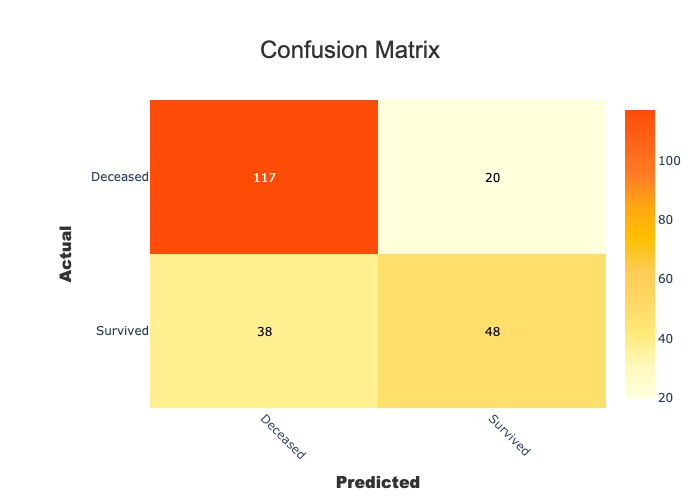

In [9]:
# Native Shapash confusion matrix based on y_target and y_pred passed to compile
xpl.plot.confusion_matrix_plot()

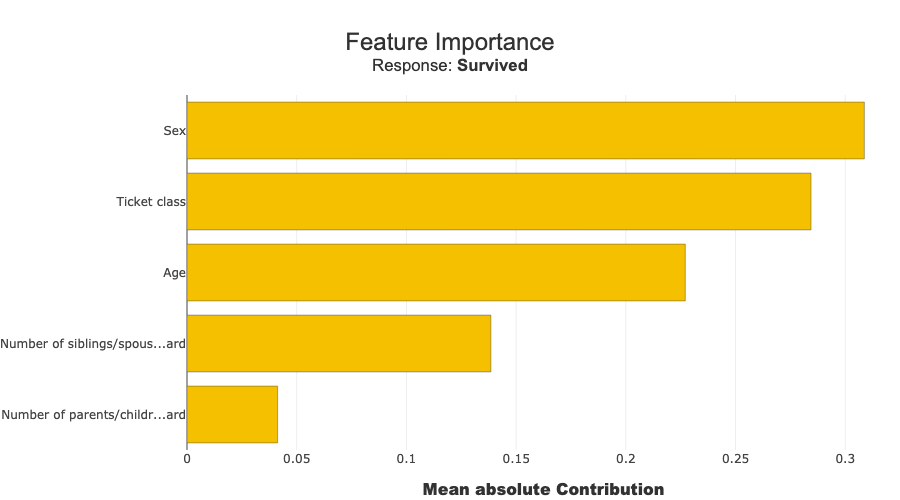

In [10]:
xpl.plot.features_importance()

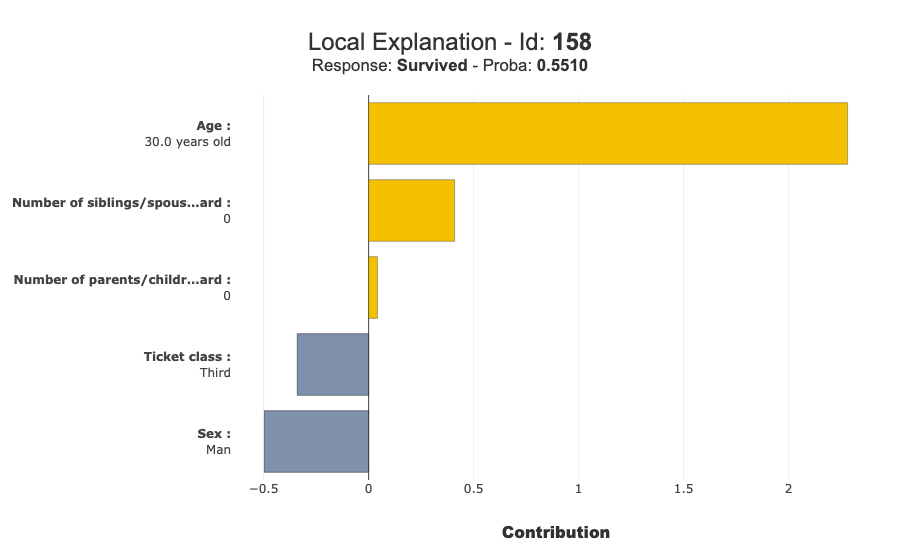

In [11]:
# Display one local explanation
xpl.plot.local_plot(index=X_test.index[0])

## 6. Launch the webapp

Use the same approach as in `shapash/webapp/webapp_launch.py`.
Run the next cell to start the local Shapash webapp.

In [12]:
# xpl.run_app(title_story='Titanic imbalanced classification tutorial')